In [13]:
import pandas as pd
import plotly.express as px

results = {}

def record(key, label, value):
    results[f"{key}. {label}"] = value

In [14]:
import pandas as pd
import os

file_path = "/content/upi_transactions_2024_cleaned.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path, on_bad_lines='skip')

    # Convert relevant columns to appropriate types, coercing errors
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df['amount_inr'] = pd.to_numeric(df['amount_inr'], errors='coerce')
    df['hour_of_day'] = pd.to_numeric(df['hour_of_day'], errors='coerce')
    df['fraud_flag'] = pd.to_numeric(df['fraud_flag'], errors='coerce').fillna(0).astype(int)

    # Handle string columns: strip whitespace and convert to lowercase
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

    # Drop rows where critical columns became NaN after coercion (e.g., timestamp)
    df.dropna(subset=['timestamp', 'amount_inr', 'hour_of_day', 'fraud_flag'], inplace=True)

    print(df.head())
else:
    print(f"Error: The file '{file_path}' was not found. Please ensure it is uploaded to your Colab environment or the path is correct.")
    # Initialize df as an empty DataFrame to avoid NameError if this cell is executed without the file.
    df = pd.DataFrame()

  transaction_id           timestamp transaction_type merchant_category  \
0  txn0000000001 2024-10-08 15:17:28              p2p     entertainment   
1  txn0000000002 2024-04-11 06:56:00              p2m           grocery   
2  txn0000000003 2024-04-02 13:27:18              p2p           grocery   
3  txn0000000004 2024-01-07 10:09:17              p2p              fuel   
4  txn0000000005 2024-01-23 19:04:23              p2p          shopping   

   amount_inr transaction_status sender_age_group receiver_age_group  \
0         868            success            26-35              18-25   
1        1011            success            26-35              26-35   
2         477            success            26-35              36-45   
3        2784            success            26-35              26-35   
4         990            success            26-35              18-25   

    sender_state sender_bank receiver_bank device_type network_type  \
0          delhi        axis           sbi   

In [ ]:
df.isnull().sum()

,0
transaction_id,0
timestamp,0
transaction_type,0
merchant_category,0
amount_inr,0
transaction_status,0
sender_age_group,0
receiver_age_group,0
sender_state,1
sender_bank,1


In [15]:
# total duplicated rows
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70345 entries, 0 to 70344
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      70345 non-null  object 
 1   timestamp           70345 non-null  object 
 2   transaction_type    70345 non-null  object 
 3   merchant_category   70345 non-null  object 
 4   amount_inr          70345 non-null  int64  
 5   transaction_status  70345 non-null  object 
 6   sender_age_group    70345 non-null  object 
 7   receiver_age_group  70345 non-null  object 
 8   sender_state        70344 non-null  object 
 9   sender_bank         70344 non-null  object 
 10  receiver_bank       70344 non-null  object 
 11  device_type         70344 non-null  object 
 12  network_type        70344 non-null  object 
 13  fraud_flag          70344 non-null  float64
 14  hour_of_day         70344 non-null  float64
 15  day_of_week         70344 non-null  object 
 16  is_w

In [16]:
df['transaction_id'].unique()

array(['txn0000000001', 'txn0000000002', 'txn0000000003', ...,
       'txn0000158268', 'txn0000158269', 'txn0000158270'], dtype=object)

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].astype(str).str.contains(r'^\s|\s$', regex=True).sum())

transaction_id 0
timestamp 0
transaction_type 0
merchant_category 0
transaction_status 0
sender_age_group 0
receiver_age_group 0
sender_state 0
sender_bank 0
receiver_bank 0
device_type 0
network_type 0
day_of_week 0


In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [17]:
print(df[col].unique())

['tuesday' 'thursday' 'sunday' 'monday' 'saturday' 'wednesday' 'friday']


In [18]:
for col in df.select_dtypes(include='object').columns:
    # Check if the column actually contains string data before converting to lower case
    # Some object columns might contain mixed types or NaNs that would raise an error if .str is directly applied
    # Also, exclude columns that might be dates represented as objects (though we might handle dates separately later)
    if df[col].apply(lambda x: isinstance(x, str)).any():
        df[col] = df[col].str.lower()

# Display the unique values for 'transaction_type' to show the effect
df['transaction_type'].unique()

array(['p2p', 'p2m', 'bill payment', 'recharge'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame


In [ ]:
df.describe()

,is_weekend
count,456004.000000
mean,0.285372
std,0.451592
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [ ]:
df.head()

,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,txn0000000001,2024-10-08 15:17:28,p2p,entertainment,NaN,success,26-35,18-25,delhi,axis,sbi,android,4g,NaN,NaN,tuesday,0.0
1,txn0000000002,2024-04-11 06:56:00,p2m,grocery,NaN,success,26-35,26-35,uttar pradesh,icici,axis,ios,4g,NaN,NaN,thursday,0.0
2,txn0000000003,2024-04-02 13:27:18,p2p,grocery,NaN,success,26-35,36-45,karnataka,yes bank,pnb,android,4g,NaN,NaN,tuesday,0.0
3,txn0000000004,2024-01-07 10:09:17,p2p,fuel,NaN,success,26-35,26-35,delhi,icici,pnb,android,5g,NaN,NaN,sunday,1.0
4,txn0000000005,2024-01-23 19:04:23,p2p,shopping,NaN,success,26-35,18-25,delhi,axis,yes bank,ios,wifi,NaN,NaN,tuesday,0.0


In [ ]:
df.tail()

,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
456016,txn0000249996,2024-11-08 22:41:43,recharge,food,NaN,success,36-45,26-35,telangana,icici,hdfc,ios,5g,NaN,NaN,friday,0.0
456017,txn0000249997,2024-12-15 02:58:03,p2p,utilities,NaN,success,36-45,26-35,rajasthan,hdfc,yes bank,android,5g,NaN,NaN,sunday,1.0
456018,txn0000249998,2024-11-27 16:33:25,p2p,food,NaN,success,26-35,18-25,west bengal,icici,icici,android,4g,NaN,NaN,wednesday,0.0
456019,txn0000249999,2024-01-05 13:31:30,recharge,healthcare,NaN,success,18-25,36-45,andhra pradesh,axis,icici,ios,4g,NaN,NaN,friday,0.0
456020,txn0000250000,2024-01-17 15:23:07,p2p,entertainment,NaN,success,18-25,26-35,telangana,axis,yes bank,android,4g,NaN,NaN,wednesday,0.0


In [ ]:
df['transaction_status'].unique()

array(['success', 'failed', 'sucesh', 'friday', '3g', '18-25', '0',
       'suc35', 'hdfc', '36-45', 'android', 'ios', nan, '26-35', '46-55'],
      dtype=object)

In [ ]:
#1 Success rate of transaction method KPI + Bar chart
import numpy as np
success_rate = (
    df.groupby("transaction_type")["transaction_status"]
    .apply(lambda x: np.mean(x.str.lower() == "success") * 100)
    .reset_index(name="success_rate_%")
    .sort_values("success_rate_%", ascending=False)
)
fig1 = px.bar(success_rate, x="transaction_type", y="success_rate_%",
              title="1. Success Rate by Payment Method", text_auto=".2f")
fig1.show()

*1. Success rate of transaction method*
For every payment method (UPI, Debit Card, Credit Card, Netbanking, Wallet, etc.), calculate what percentage of transactions using that method were completed successfully. This tells you which payment methods are most reliable from the user's perspective

In [ ]:
#2.failure rate of transcation method
# =================================================================
# Calculate failure rate from the 'success_rate_%' column of the success_rate DataFrame
failure_rate_values = (100 - success_rate['success_rate_%']).round(2)

# Create a new DataFrame for failure_rate including 'transaction_type'
failure_rate = pd.DataFrame({
    'transaction_type': success_rate['transaction_type'],
    'failure_rate_%': failure_rate_values
})

print("Q2 Failure rate by method:\n", failure_rate)

fig2 = px.bar(failure_rate, x='transaction_type', y='failure_rate_%',
              title="2. Failure Rate by Transaction Method (%)", text_auto=".2f")
fig2.show()

Q2 Failure rate by method:
    transaction_type  failure_rate_%
6      bill payment            4.90
11              p2m            4.95
12              p2p            4.97
14         recharge            5.08
3             36-45          100.00
0                 0          100.00
2              2192          100.00
1               186          100.00
7              fuel          100.00
5              axis          100.00
4                4g          100.00
8             icici          100.00
10              p26          100.00
9        p2 pradesh          100.00
13       rechargana          100.00
15      recharghdfc          100.00



*2. Failure rate of transaction method*
The opposite of #1 — for every payment method, what percentage of transactions failed or got declined. High failure rates on a method could point to a technical/gateway issue worth investigating.



In [21]:
#3.Highest transcations age group
#4Lowest transaction age group
# Bar chart
age_group_counts = df['sender_age_group'].value_counts().reset_index()
age_group_counts.columns = ["age_group", "txn_count"]
highest_age_group = age_group_counts.iloc[0]
lowest_age_group = age_group_counts.iloc[-1]
results["highest_age_group"] = highest_age_group
results["lowest_age_group"] = lowest_age_group
fig3 = px.bar(age_group_counts, x="age_group", y="txn_count",
              title="3/4. Transactions by Age Group")
fig3.show()

*3. Highest transaction age group*
Group all users into age brackets (like 18-25, 26-35, 36-45, etc.) and find which bracket has the highest transaction count. This shows which age demographic is most active on the platform.

*4. Lowest transaction age group*
Same grouping as above, but identifying which age bracket transacts the least — useful for understanding underserved or less-engaged user segments.



In [20]:
# 5.Highest Transcation Bank
# 6.Lowest transaction bank
# Bar chart
bank_counts = df['sender_bank'].value_counts().reset_index()
bank_counts.columns = ["bank", "txn_count"]
highest_bank = bank_counts.iloc[0]
lowest_bank = bank_counts.iloc[-1]
results["highest_bank"] = highest_bank
results["lowest_bank"] = lowest_bank
fig4 = px.bar(bank_counts, x="bank", y="txn_count", title="5/6. Transactions by Bank")
fig4.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

pd.set_option('display.max_columns', None)

In [22]:
#7Most repeated payment method
# KPI + Bar chart

# df is already loaded and cleaned in SqFsCPmpA8YV
# Remove redundant df loading and type conversions from this cell

method_counts = df['transaction_type'].value_counts()
results["7. Most repeated transaction method"] = method_counts.idxmax()
fig = px.pie(values=method_counts.values, names=method_counts.index,
             title="Transaction Method Distribution")
fig.show()

*7. Most repeated payment method*
Simply put — if you list every transaction's payment method and find the mode (most frequently occurring value), which method comes up most often overall.



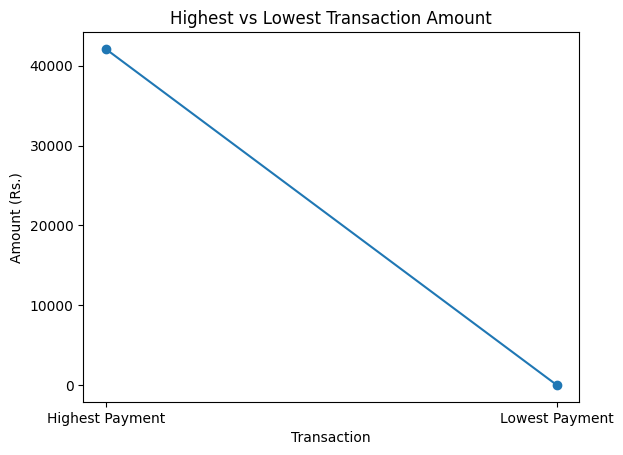

In [37]:

#8&9 highest and lowest amount
import matplotlib.pyplot as plt

categories = ["Highest Payment", "Lowest Payment"]
amounts = [max_row["amount_inr"], min_row["amount_inr"]]

plt.plot(categories, amounts, marker="o")

plt.title("Highest vs Lowest Transaction Amount")
plt.xlabel("Transaction")
plt.ylabel("Amount (Rs.)")

plt.show()

In [24]:
import pandas as pd
import numpy as np
import plotly.express as px

pd.set_option('display.max_columns', None)

# 'timestamp' conversion and dropna is now handled in SqFsCPmpA8YV
# Create a 'month' column from the timestamp
df['month'] = df['timestamp'].dt.strftime('%B')

# 10. Month-wise transactions
# ==================================================================
month_order = ["january","february","march","april","may","june","july",
                "august","september","october","november","december"]
month_counts = df['month'].value_counts().reindex(month_order)
results["10. Month-wise transactions"] = month_counts
fig = px.line(month_counts, title="Month-wise Transactions", markers=True)
fig.show()

*10. Month-wise transactions*
Count how many transactions happened in each calendar month (Jan, Feb, Mar...) across the dataset's time range. Helps spot seasonal trends or monthly growth patterns.


In [ ]:
# Create a 'year' column from the timestamp
df['year'] = df['timestamp'].dt.year

# 11. Year-wise transactions
# ==================================================================
year_counts = df['year'].value_counts().sort_index()
results["11. Year-wise transactions"] = year_counts
fig = px.bar(year_counts, title="Year-wise Transactions")
fig.show()

*11. Year-wise transactions*
Count how many transactions happened in each year present in the data — useful if your dataset spans multiple years, to see year-over-year growth or decline.



In [ ]:
# Create 'hour_of_day' column if it doesn't exist
if 'hour_of_day' not in df.columns:
    df['hour_of_day'] = df['timestamp'].dt.hour

# ==================================================================
# 12. Highest number of transactions by hour ("working hours")
# ==================================================================
hour_counts = df['hour_of_day'].value_counts().sort_index()
results["12. Busiest hour of day (highest txn count)"] = hour_counts.idxmax()
fig = px.bar(hour_counts, title="Transactions by Hour of Day")
fig.show()

*12. Highest number of working hours*
Identify which hour of the day (0-23) has the highest transaction volume — essentially the "peak hour" when most transactions occur. Useful for server load planning or marketing timing.


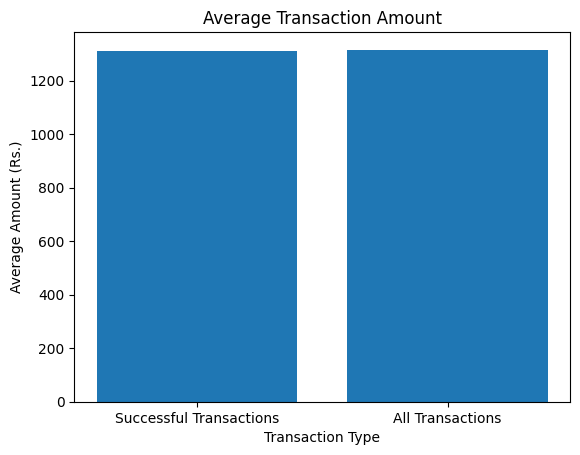

In [36]:
#average revenue
import matplotlib.pyplot as plt

categories = ["Successful Transactions", "All Transactions"]
averages = [avg_revenue_success, avg_revenue_all]

plt.bar(categories, averages)

plt.title("Average Transaction Amount")
plt.xlabel("Transaction Type")
plt.ylabel("Average Amount (Rs.)")

plt.show()

In [ ]:
# 14. Transactions by device t
device_counts = df['device_type'].value_counts()
results["14. Transactions by device type"] = device_counts
fig = px.pie(values=device_counts.values, names=device_counts.index,
             title="Transactions by Device Type")
fig.show()


*14. Transaction by device type*
Break down transaction counts by the device used to make them (Mobile, Desktop, Tablet) — shows which platform users prefer.



In [ ]:

# 15 & 16. State with more / fewer users (transactions)
state_counts = df['sender_state'].value_counts()
results["15. State with most transactions/users"] = state_counts.idxmax()
results["16. State with fewest transactions/users"] = state_counts.idxmin()
fig = px.bar(state_counts.sort_values(ascending=False), title="Transactions by State")
fig.show()



*15. State with more users*
Which Indian state has the highest count of unique users or transactions originating from it — shows geographic strength.

*16. State with less users*
Which state has the fewest users/transactions — shows geographic weakness or areas needing expansion focus.



In [ ]:
# 17. Most repeated day for transactions
day_counts = df['day_of_week'].value_counts()
results["17. Most repeated transaction day"] = day_counts.idxmax()
fig = px.bar(day_counts, title="Transactions by Day of Week")
fig.show()


*17. Repeated day for transaction*
Look at the day of the week (Monday through Sunday) for every transaction and find which day occurs most often — reveals weekly usage patterns (e.g., are weekends busier?).



In [ ]:
# 18. Highest transaction type
type_counts = df['transaction_type'].value_counts()
results["18. Highest transaction type"] = type_counts.idxmax()
fig = px.bar(type_counts, title="Transactions by Type")
fig.show()
# **bold text**


*18. Highest transaction type*
If transactions are categorized by type (like P2P – person to person, P2M – person to merchant, refund, etc.), find which type has the highest count.



In [ ]:
# 19. Average transactions per day
daily_counts = df.groupby(df['timestamp'].dt.date).size()
results["21. Average transactions per day"] = round(daily_counts.mean(), 2)
fig = px.line(daily_counts, title="Daily Transaction Count Over 2024")
fig.show()


*19. No. of transaction IDs*
Simply the total count of unique transaction IDs in the dataset — tells you the overall size/volume of the data.


In [ ]:
# 20. Merchant categories with high transactions
import pandas as pd
import plotly.express as px

# Load your data
# df = pd.read_csv('transactions.csv')

# Aggregate transaction count by merchant category
category_summary = (
    df.groupby('merchant_category')['amount_inr']
      .count()
      .reset_index(name='transaction_count')
      .sort_values('transaction_count', ascending=False)
)

print(category_summary)

# Plot
fig = px.bar(
    category_summary,
    x='merchant_category',
    y='transaction_count',
    title='Transactions by Merchant Category'
)
fig.show()

   merchant_category  transaction_count
5            Grocery              91229
3               Food              68341
8           Shopping              54692
4               Fuel              45563
7              Other              45310
10         Utilities              40657
2      Entertainment              36596
9          Transport              36577
6         Healthcare              23146
1          Education              13892
0                  0                  1


*22. Merchant categories with high transactions*
Group transactions by merchant category (e.g., groceries, fuel, e-commerce, entertainment) and rank them by transaction count — shows which business categories drive the most activity.


In [ ]:
# 21 Average sender group Bar chartCount by sender age group
age_group_counts = (
    df['sender_age_group']
      .value_counts()
      .reset_index(name='count')
      .rename(columns={'index': 'age_group'})
)

# Plot
fig = px.bar(
    age_group_counts,
    x='sender_age_group',
    y='count',
    title='Sender Age Group Distribution'
)
fig.show()

*23. Average sender group*
Identify the most common age group among the people initiating/sending the transactions — helps understand the typical "sender" demographic.


In [ ]:
print(df.columns.tolist())

[]


In [27]:
# 22. Average receiver age group - Bar chart
# ==================================================================
age_group_counts = (
    df['receiver_age_group']
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'receiver_age_group': 'age_group'})   # <-- fixed column name
)

results["24. Most common receiver age group"] = age_group_counts.iloc[0]['age_group']

fig = px.bar(
    age_group_counts,
    x='age_group',
    y='count',
    title='Receiver Age Group Distribution',
    labels={'age_group': 'Receiver Age Group', 'count': 'Transaction Count'}
)
fig.update_layout(template="plotly_white")
fig.show()


 Average receiver group*
Identify the most common age group among the people receiving the transactions — helps understand the typical "receiver" demographic.

# New section

In [28]:
# 23. State with highest transactions through 5G
# ==================================================================
g5 = df[df['network_type'].str.strip().str.lower() == '5g']

if not g5.empty:
    g5_by_state = g5['sender_state'].value_counts().reset_index()
    g5_by_state.columns = ['sender_state', 'count']
    g5_by_state = g5_by_state.sort_values('count', ascending=False)

    results["25. State with highest 5G transactions"] = g5_by_state.iloc[0]['sender_state']

    fig = px.bar(
        g5_by_state,
        x='sender_state', y='count',
        title="5G Transactions by State",
        labels={'sender_state': 'State', 'count': 'Transaction Count'}
    )
    fig.update_layout(template="plotly_white", xaxis_tickangle=-45)
    fig.show()
else:
    print("No rows matched network_type == '5G' — check the actual values with df['network_type'].unique()")

 Which state has the highest transactions through 5G?*
Filter only the transactions made over a 5G network connection, then find which state has the most of them — shows 5G adoption geography.

# New section

In [29]:
# 24. Highest revenue-generating "city" (no city column -> using state)
state_revenue = df.groupby('sender_state')['amount_inr'].sum().sort_values(ascending=False)
results["29. Highest revenue-generating state (no city column in data)"] = state_revenue.idxmax()
fig = px.bar(state_revenue, title="Revenue by State (INR)")
fig.show()



 Highest revenue-generating city*
Sum up the total transaction amount (not just count) for each city, and find which city generated the most total revenue — different from just "most transactions," since it's about total money value.

# New section

In [30]:
# 25. State with lowest fraud rate
state_fraud = df.groupby('sender_state')['fraud_flag'].mean() * 100
results["30. State with lowest fraud rate"] = state_fraud.idxmin()
fig = px.bar(state_fraud.sort_values(), title="Fraud Rate by State (%)")
fig.show()



 Which state has the lowest fraud rate?*
Calculate the fraud percentage separately for each state, then find which state has the smallest proportion of fraudulent transactions — indicates the "safest" state by this metric.



In [ ]:
#26.highest transcation by state wise
state_transaction_counts = df['sender_state'].value_counts().reset_index()
state_transaction_counts.columns = ['State', 'Transaction Count']

fig_states = px.bar(
    state_transaction_counts,
    x='State',
    y='Transaction Count',
    title='Transaction Counts by Sender State',
    labels={'State': 'Sender State', 'Transaction Count': 'Number of Transactions'},
    text='Transaction Count'
)
fig_states.update_traces(textposition='outside')
fig_states.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')
fig_states.show()

In [41]:
#27.no of states
import plotly.express as px

# Count transactions for each state
state_counts = df["sender_state"].value_counts().reset_index()
state_counts.columns = ["state", "count"]

# Column chart
fig = px.bar(
    state_counts,
    x="state",
    y="count",
    title="Number of Transactions by State"
)

fig.update_layout(
    xaxis_title="State",
    yaxis_title="Number of Transactions",
    xaxis_tickangle=-45
)

fig.show()

*31. How many different states are present?*
Simply count the number of unique state names/values in the dataset — tells you the geographic spread/coverage of the data.



In [ ]:
# Simple HTML dashboard combining the existing Plotly outputs
import os
import plotly.io as pio
from IPython.display import HTML, display

dashboard_figures = []
for dashboard_name in [
    "fig1", "fig2", "fig3", "fig4", "fig", "fig_states"
]:
    dashboard_object = globals().get(dashboard_name)
    if dashboard_object is not None and hasattr(dashboard_object, "to_html"):
        dashboard_figures.append((dashboard_name, dashboard_object))

dashboard_cards = []
for dashboard_key, dashboard_value in results.items():
    if hasattr(dashboard_value, "to_dict"):
        dashboard_value = dashboard_value.to_dict()
    dashboard_cards.append(
        f'<div class="card"><div class="card-title">{dashboard_key}</div>'
        f'<div class="card-value">{dashboard_value}</div></div>'
    )

dashboard_chart_html = []
for dashboard_index, (dashboard_name, dashboard_figure) in enumerate(dashboard_figures):
    dashboard_plot = pio.to_html(
        dashboard_figure,
        full_html=False,
        include_plotlyjs="cdn" if dashboard_index == 0 else False,
    )
    dashboard_chart_html.append(
        f'<div class="chart">{dashboard_plot}</div>'
    )

dashboard_html = f"""
<!doctype html>
<html>
<head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <title>UPI Transactions Dashboard</title>
    <style>
        body {{ margin: 0; padding: 28px; background: #f4f7fb;
               font-family: Arial, sans-serif; color: #172033; }}
        h1 {{ margin: 0 0 8px; color: #102a43; }}
        .subtitle {{ margin-bottom: 24px; color: #627d98; }}
        .cards {{ display: grid; grid-template-columns:
                  repeat(auto-fit, minmax(190px, 1fr)); gap: 14px;
                  margin-bottom: 24px; }}
        .card, .chart {{ background: white; border-radius: 12px;
                          box-shadow: 0 2px 10px #102a4315; }}
        .card {{ padding: 16px; }}
        .card-title {{ font-size: 13px; color: #627d98; margin-bottom: 8px; }}
        .card-value {{ font-size: 20px; font-weight: 700; color: #0b7285;
                       word-break: break-word; }}
        .charts {{ display: grid; grid-template-columns:
                   repeat(auto-fit, minmax(420px, 1fr)); gap: 18px; }}
        .chart {{ padding: 8px; min-height: 360px; }}
    </style>
</head>
<body>
    <h1>UPI Transactions Dashboard</h1>
    <div class="subtitle">Interactive summary of the analysis outputs</div>
    <div class="cards">{''.join(dashboard_cards)}</div>
    <div class="charts">{''.join(dashboard_chart_html)}</div>
</body>
</html>
"""

dashboard_output_path = "upi_transactions_dashboard.html"
with open(dashboard_output_path, "w", encoding="utf-8") as dashboard_file:
    dashboard_file.write(dashboard_html)

display(HTML(dashboard_html))
print(f"Dashboard saved to {dashboard_output_path}")
